### ============================================================
## CARDIOVASCULAR DISEASE PREDICTION
## Notebook 1: Data Preprocessing & EDA
## MSc IT with Data Analytics — UWS 2025-26
### ============================================================

# Import

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings

In [7]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

# --- Load Dataset ---

In [8]:
# --- Load Dataset ---
df = pd.read_csv('../data/cardio_train.csv', sep=';')

# --- Initial Exploration ---
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (70000, 13)

Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


##### INITIAL EDA — Raw Data (Before Cleaning)

### Check Distribution of Age (raw days)

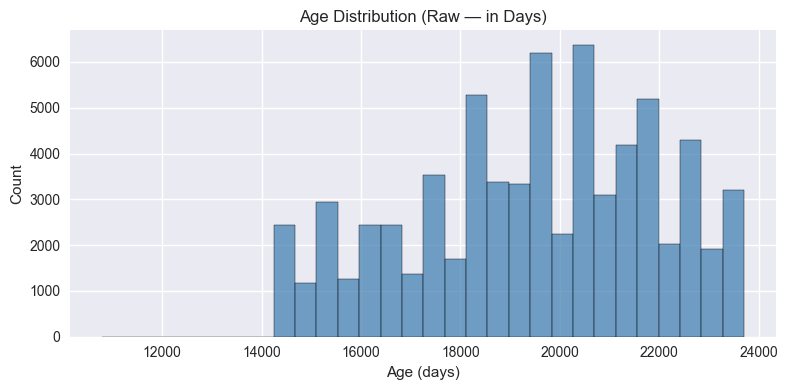

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=30, color='steelblue')
plt.title('Age Distribution (Raw — in Days)')
plt.xlabel('Age (days)')
plt.tight_layout()
plt.savefig('../outputs/raw_age_distribution.png', dpi=150)
plt.show()

### Box plots to show outliers in key columns

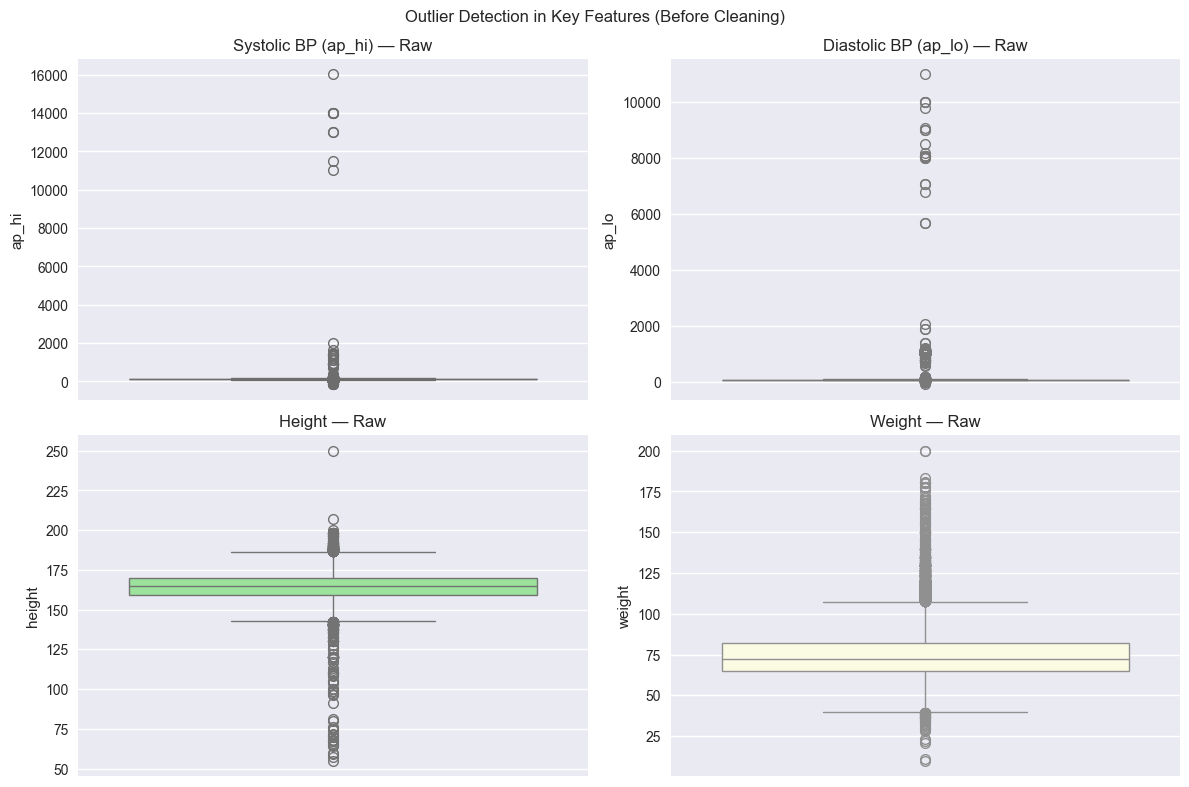

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(y=df['ap_hi'], ax=axes[0,0], color='salmon')
axes[0,0].set_title('Systolic BP (ap_hi) — Raw')

sns.boxplot(y=df['ap_lo'], ax=axes[0,1], color='lightblue')
axes[0,1].set_title('Diastolic BP (ap_lo) — Raw')

sns.boxplot(y=df['height'], ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Height — Raw')

sns.boxplot(y=df['weight'], ax=axes[1,1], color='lightyellow')
axes[1,1].set_title('Weight — Raw')

plt.suptitle('Outlier Detection in Key Features (Before Cleaning)')
plt.tight_layout()
plt.savefig('../outputs/raw_outliers_boxplot.png', dpi=150)
plt.show()

## Drop ID column

### Class Balance Raw

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38592\3546832696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='Set2')


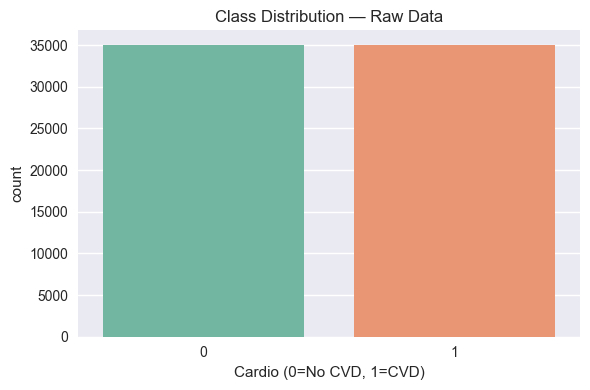

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df, palette='Set2')
plt.title('Class Distribution — Raw Data')
plt.xlabel('Cardio (0=No CVD, 1=CVD)')
plt.tight_layout()
plt.savefig('../outputs/raw_class_distribution.png', dpi=150)
plt.show()

In [12]:
# --- Drop ID Column ---
df = df.drop('id', axis=1)
print("ID column dropped. New shape:", df.shape)

ID column dropped. New shape: (70000, 12)


## Step 2 — Convert age from days to years:

In [13]:
# --- Convert Age from Days to Years ---
df['age'] = (df['age'] / 365).round(1)

print("Age conversion complete")
print(f"Age range: {df['age'].min()} to {df['age'].max()} years")
print(f"Mean age: {df['age'].mean():.1f} years")

Age conversion complete
Age range: 29.6 to 65.0 years
Mean age: 53.3 years


### Step 3 — Calculate BMI: BMI = weight (kg) / height (m)²

In [14]:
# --- Calculate BMI ---
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

print("BMI column created")
print(f"BMI range: {df['bmi'].min():.1f} to {df['bmi'].max():.1f}")
print(f"Mean BMI: {df['bmi'].mean():.1f}")
print(f"\nBMI Statistics:")
print(df['bmi'].describe())

BMI column created
BMI range: 3.5 to 298.7
Mean BMI: 27.6

BMI Statistics:
count    70000.000000
mean        27.556513
std          6.091511
min          3.471784
25%         23.875115
50%         26.374068
75%         30.222222
max        298.666667
Name: bmi, dtype: float64


### Step 4 — Remove Outliers

In [15]:
# --- Remove Outliers Using Clinical Reference Ranges ---

print("Shape before outlier removal:", df.shape)

# Blood pressure - clinically valid ranges
df = df[df['ap_hi'] >= 70]
df = df[df['ap_hi'] <= 250]
df = df[df['ap_lo'] >= 40]
df = df[df['ap_lo'] <= 150]

# ap_lo must always be less than ap_hi
df = df[df['ap_lo'] < df['ap_hi']]

# Height - realistic adult range in cm
df = df[df['height'] >= 140]
df = df[df['height'] <= 210]

# Weight - realistic adult range in kg
df = df[df['weight'] >= 40]
df = df[df['weight'] <= 180]

# BMI - clinically valid range
df = df[df['bmi'] >= 10]
df = df[df['bmi'] <= 60]

print("Shape after outlier removal:", df.shape)
print(f"Rows removed: {70000 - len(df)}")

Shape before outlier removal: (70000, 13)
Shape after outlier removal: (68455, 13)
Rows removed: 1545


### Step 5 — Remove Impossible Blood Pressure Values

In [16]:
# --- Verify Blood Pressure Logic ---
print("Checking blood pressure consistency...")
print(f"Cases where ap_lo >= ap_hi: {len(df[df['ap_lo'] >= df['ap_hi']])}")

# Check clean ranges
print(f"\nap_hi range: {df['ap_hi'].min()} to {df['ap_hi'].max()}")
print(f"ap_lo range: {df['ap_lo'].min()} to {df['ap_lo'].max()}")
print(f"BMI range: {df['bmi'].min():.1f} to {df['bmi'].max():.1f}")
print(f"Height range: {df['height'].min()} to {df['height'].max()}")
print(f"Weight range: {df['weight'].min()} to {df['weight'].max()}")

print("\nShape confirmed:", df.shape)

Checking blood pressure consistency...
Cases where ap_lo >= ap_hi: 0

ap_hi range: 70 to 240
ap_lo range: 40 to 150
BMI range: 13.5 to 59.5
Height range: 140 to 207
Weight range: 40.0 to 180.0

Shape confirmed: (68455, 13)


### Step 6 — Check Class Balance

In [17]:
# --- Check Class Balance ---
print("Target Variable Distribution:")
print(df['cardio'].value_counts())
print("\nPercentage:")
print(df['cardio'].value_counts(normalize=True) * 100)

Target Variable Distribution:
cardio
0    34581
1    33874
Name: count, dtype: int64

Percentage:
cardio
0    50.516398
1    49.483602
Name: proportion, dtype: float64


### Step 7 — Feature Engineering & Categorisation

In [21]:
# --- BMI Category ---
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
# --- Age Category ---
def age_category(age):
    if age < 40:
        return 'Under 40'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

df['age_category'] = df['age'].apply(age_category)
print(df['bmi_category'].value_counts())
print(df['age_category'].value_counts())

bmi_category
Normal         25415
Overweight     24609
Obese          17833
Underweight      598
Name: count, dtype: int64
age_category
50-59       34703
40-49       19086
60+         13093
Under 40     1573
Name: count, dtype: int64


### Save cleaned data

In [19]:
# --- Final Check Before Export ---
print("Final dataset info:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

# --- Export Clean Dataset ---
df.to_csv('../data/cardio_clean.csv', index=False)
print("\nClean dataset exported successfully to data/cardio_clean.csv!")

Final dataset info:
Shape: (68455, 15)

Columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'bmi_category', 'age_category']

Missing values: 0

Clean dataset exported successfully to data/cardio_clean.csv!


### Data Saving for Visualization and saving it 

In [20]:
# --- Categorical Value Mapping for EDA ---
df_eda = df.copy()  # Keep original numeric for ML, use this copy for charts only

df_eda['gender'] = df_eda['gender'].map({1: 'Female', 2: 'Male'})
df_eda['cholesterol'] = df_eda['cholesterol'].map({1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'})
df_eda['gluc'] = df_eda['gluc'].map({1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'})
df_eda['smoke'] = df_eda['smoke'].map({0: 'Non-Smoker', 1: 'Smoker'})
df_eda['alco'] = df_eda['alco'].map({0: 'No', 1: 'Yes'})
df_eda['active'] = df_eda['active'].map({0: 'No', 1: 'Yes'})
df_eda['cardio'] = df_eda['cardio'].map({0: 'No CVD', 1: 'CVD'})

print("Categorical mapping complete!")
print(df_eda[['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']].head())

# --- Export Visualisation Dataset ---
df_eda.to_csv('../data/cardio_visualisation.csv', index=False)
print("Visualisation dataset exported successfully to data/cardio_visualisation.csv!")

Categorical mapping complete!
   gender        cholesterol    gluc       smoke alco active  cardio
0    Male             Normal  Normal  Non-Smoker   No    Yes  No CVD
1  Female  Well Above Normal  Normal  Non-Smoker   No    Yes     CVD
2  Female  Well Above Normal  Normal  Non-Smoker   No     No     CVD
3    Male             Normal  Normal  Non-Smoker   No    Yes     CVD
4  Female             Normal  Normal  Non-Smoker   No     No  No CVD
Visualisation dataset exported successfully to data/cardio_visualisation.csv!
